# How Giants Grow — Weighing a Supermassive Black Hole

A single SDSS spectrum, a little PCA, one curve fit, and we'll measure the
**mass of a supermassive black hole** at the heart of a galaxy ~600 million
light-years away.

**Target for today:** Markarian 79 (Mrk 79), a nearby **Seyfert-1 galaxy**.
A "Seyfert-1" is a galaxy whose central black hole is actively eating gas, and
the gas is spinning so fast that the light it emits gets smeared into very
**broad emission lines**. We can read the gas's speed straight off those
broad lines — and from that get the black hole's mass.

**By the end of this workbook you will have:**

1. Plotted a real SDSS spectrum.
2. Used PCA to **separate** the galaxy starlight from the AGN (black-hole) light.
3. Fit a **broad Hβ emission line** with a Gaussian.
4. Computed Mrk 79's black-hole mass in solar masses.

> **Heads up — Python newcomers:** every code cell ends with a few lines that
> *print or plot* what just happened. Run cells with `Shift + Enter`. If you
> hit an error, raise your hand — and look for the line near the bottom of the
> error message that says what went wrong.


## 0. Setup

This first cell loads all the tools we'll need. Run it once.

If anything fails with a `ModuleNotFoundError`, run this in a new cell:

```python
!pip install numpy scipy matplotlib astropy pandas
```


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
import glob, os

# Make plots a little nicer
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Setup complete!")

Setup complete!


## 1. Load the SDSS spectrum

A spectrum is a graph: how bright the light is (**flux**) at each wavelength.
SDSS gives us spectra of millions of galaxies and quasars.

We've pre-downloaded one spectrum for you. It's stored in a `.fits` file (the
standard astronomy format). The cell below opens it and pulls out the
wavelength array and the flux array.

> **Why pre-download?** SDSS lets you grab any spectrum directly from the
> internet, but downloads can be slow or fail in class. We've cached one in
> `content/`. There's an *optional* cell at the very end of the notebook that
> shows how to download a different one yourself.


In [8]:
# Spectrum file (Markarian 79 -- a nearby Seyfert-1 AGN)
spec_path = "content/spec_542_51993_560.fits"
#z = 0.13230   # redshift looked up from the SDSS catalog

with fits.open(spec_path) as hdul:
    data = hdul[1].data            # the spectrum is in extension 1
    flux       = data["flux"]      # observed flux, units 10^-17 erg/s/cm^2/A
    loglam     = data["loglam"]    # log10 of wavelength in Angstroms
    ivar       = data["ivar"]      # inverse variance (we'll use this later)
    specobj = hdul[2].data
    z       = float(specobj["Z"][0])
    z_err   = float(specobj["Z_ERR"][0])
    zwarn   = int(specobj["ZWARNING"][0])
    sclass  = specobj["CLASS"][0]
    subcl   = specobj["SUBCLASS"][0]

wavelength = 10 ** loglam          # back to Angstroms

print(f"Loaded {len(wavelength)} wavelength points")
print(f"Wavelength range: {wavelength.min():.0f} - {wavelength.max():.0f} A (observed frame)")
print(f"Redshift z = {z:.7f} ± {z_err:.7f}   class = {sclass} / {subcl}   ZWARNING = {zwarn}")


Loaded 3834 wavelength points
Wavelength range: 3808 - 9204 A (observed frame)
Redshift z = 0.1322984 ± 0.0000329   class = QSO / BROADLINE   ZWARNING = 0


### Plot the spectrum

Run the cell. You should see a smooth curve with a few **big bumps** — those
bumps are emission lines from glowing gas around the central black hole.

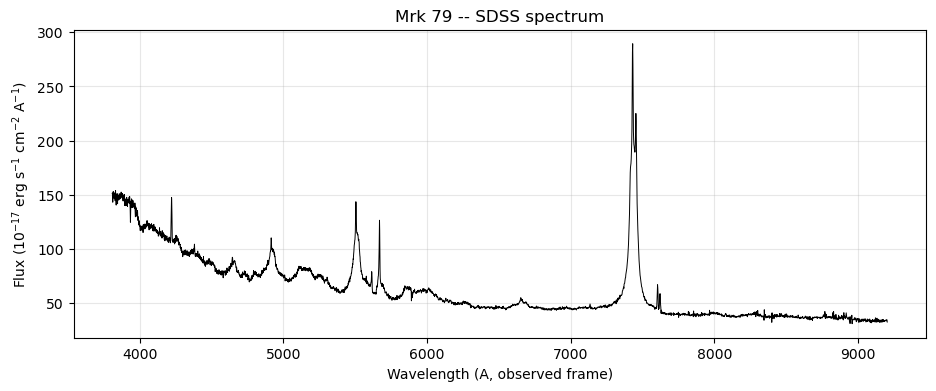

In [11]:
plt.figure(figsize=(11, 4))
plt.plot(wavelength, flux, lw=0.7, color="black")
plt.xlabel("Wavelength (A, observed frame)")
plt.ylabel(r"Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ A$^{-1}$)")
plt.title("Mrk 79 -- SDSS spectrum")
plt.show()

### Exercise 1 — Where is Hβ?

The blue Balmer line **Hβ** has a *rest-frame* wavelength of **4861 Å**. Because
the galaxy is moving away from us, the line shows up at a longer wavelength:

$$\lambda_\text{observed} \;=\; \lambda_\text{rest} \times (1 + z)$$

Compute the observed wavelength of Hβ for Mrk 79 and replace `...` with your
answer. The line should land near a **broad bump** in the spectrum.

Hb should be observed at 5504.1 A


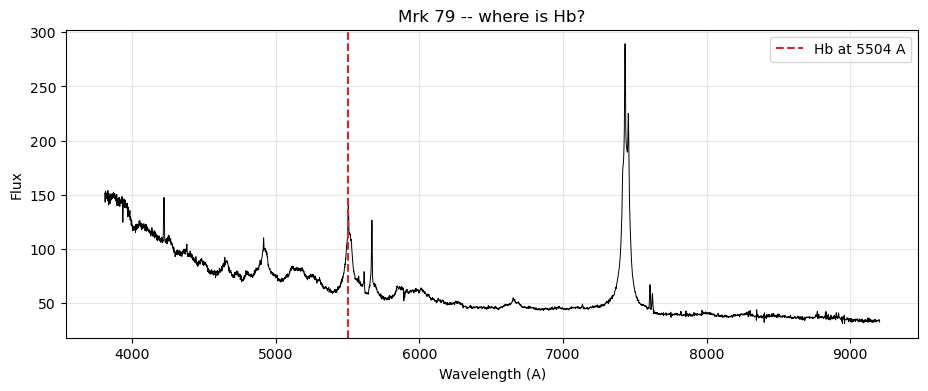

In [14]:
# === Exercise 1 ===
# Replace `None` below with your formula, then re-run the cell.
# Hint: observed wavelength = rest wavelength * (1 + z)

hbeta_rest = 4861.0
hbeta_obs  = (1+z)*4861.0 #None        # <-- YOUR CODE HERE

if hbeta_obs is None:
    print("TO DO: replace `None` above with your formula, then re-run this cell.")
else:
    print(f"Hb should be observed at {hbeta_obs:.1f} A")
    plt.figure(figsize=(11, 4))
    plt.plot(wavelength, flux, lw=0.7, color="black")
    plt.axvline(hbeta_obs, color="C3", ls="--", label=f"Hb at {hbeta_obs:.0f} A")
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.title("Mrk 79 -- where is Hb?")
    plt.legend()
    plt.show()

## 2. Separate the galaxy from the AGN with PCA

The light we see from Mrk 79 is actually **two things mixed together**:

1. **Starlight** from the host galaxy (billions of normal stars).
2. **AGN light** from gas swirling around the central black hole.

To measure the black hole, we need to **isolate the AGN component**. We'll do
that with **Principal Component Analysis (PCA)**.

### What is PCA, in one paragraph?

Imagine you have many recipes for cookies. Each recipe is a long list of
ingredients. PCA says: out of all those recipes, what are the few key
"ingredient patterns" that explain most of the differences? You can then
*describe any cookie* as a sum of those patterns. PCA does the same for
spectra: out of thousands of SDSS spectra, **a small number of "template
spectra"** (called *eigenspectra*) can rebuild almost any galaxy or quasar.

We have:

* **10 galaxy templates** (`galaxyKL_eigSpec_*.dat`) — patterns that span
  normal galaxies.
* **50 quasar templates** (`eigSpec_qso_*.dat`) — patterns that span quasars
  (a.k.a. AGN).

If we fit Mrk 79's spectrum as **(galaxy templates) + (quasar templates)**, the
galaxy part captures the starlight and the quasar part captures the AGN. ✨


### Load the templates

The templates are plain text files: column 1 is wavelength (rest frame), column
2 is flux. They live in `content/`.

Found 10 galaxy templates
Found 50 quasar templates


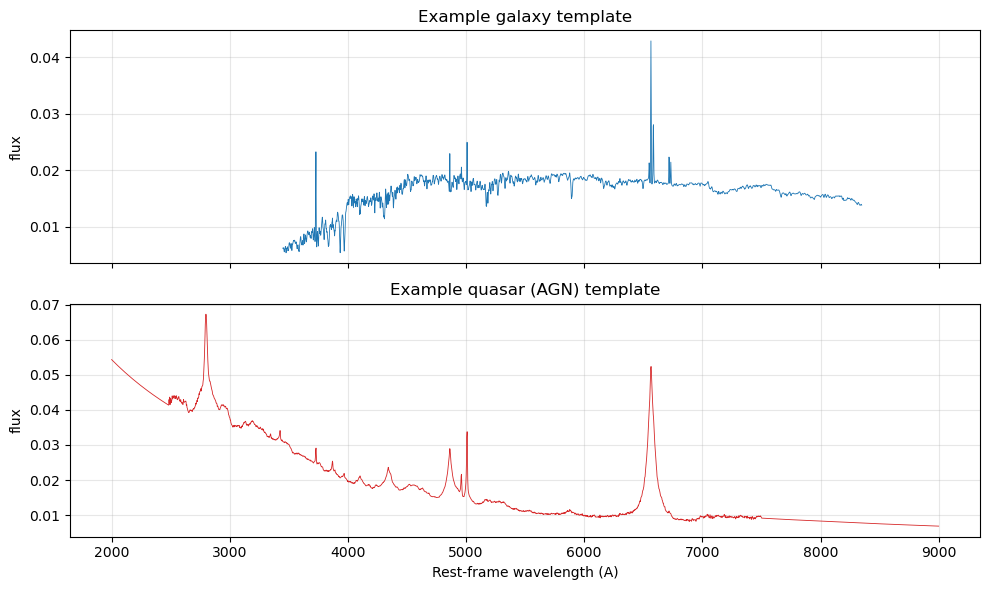

In [18]:
def load_template(path):
    """Read one .dat template file and return (wavelength, flux)."""
    arr = np.loadtxt(path)
    return arr[:, 0], arr[:, 1]

galaxy_files = sorted(glob.glob("content/galaxyKL_eigSpec_*.dat"))
quasar_files = sorted(glob.glob("content/eigSpec_qso_*.dat"))

print(f"Found {len(galaxy_files)} galaxy templates")
print(f"Found {len(quasar_files)} quasar templates")

# Just look at the first one of each so we can see what they look like
lam_g, flux_g = load_template(galaxy_files[0])
lam_q, flux_q = load_template(quasar_files[0])

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(lam_g, flux_g, lw=0.6, color="C0")
axes[0].set_title("Example galaxy template")
axes[0].set_ylabel("flux")
axes[1].plot(lam_q, flux_q, lw=0.6, color="C3")
axes[1].set_title("Example quasar (AGN) template")
axes[1].set_xlabel("Rest-frame wavelength (A)")
axes[1].set_ylabel("flux")
plt.tight_layout()
plt.show()

### Put templates and observation on the same wavelength grid

The templates are in the **rest frame**. Mrk 79's spectrum is in the **observed
frame**. We need to redshift the templates (multiply their wavelengths by
$(1+z)$) and then evaluate them on the same wavelength grid as our observation.

We'll use `np.interp` — give it the new wavelength axis and the original
$(\lambda, f)$ points, and it returns flux values on the new axis.

In [21]:
def shift_and_interp(lam_rest, flux_rest, z, lam_target):
    """Redshift a template and resample it onto lam_target."""
    lam_obs = lam_rest * (1 + z)
    return np.interp(lam_target, lam_obs, flux_rest, left=0.0, right=0.0)

# Build the design matrix: each column is one template, evaluated on `wavelength`
gal_matrix = np.column_stack([
    shift_and_interp(*load_template(f), z=z, lam_target=wavelength)
    for f in galaxy_files
])
qso_matrix = np.column_stack([
    shift_and_interp(*load_template(f), z=z, lam_target=wavelength)
    for f in quasar_files
])

print("galaxy matrix shape:", gal_matrix.shape, " (n_pixels x n_templates)")
print("quasar matrix shape:", qso_matrix.shape)

galaxy matrix shape: (3834, 10)  (n_pixels x n_templates)
quasar matrix shape: (3834, 50)


### Solve the linear least-squares problem

We want to find numbers $a_1, a_2, \dots$ (galaxy weights) and $b_1, b_2, \dots$
(quasar weights) so that

$$\text{observed flux} \;\approx\; a_1 g_1 + a_2 g_2 + \dots + b_1 q_1 + b_2 q_2 + \dots$$

`numpy.linalg.lstsq` finds the weights that make the difference (squared, summed
over all wavelengths) as small as possible.

We'll restrict the fit to a sensible wavelength range where **both** the galaxy
and quasar templates have data — roughly 3800–7800 Å observed.

In [24]:
# Combine into one big matrix A of shape (n_pixels, n_galaxy + n_quasar)
A = np.hstack([gal_matrix, qso_matrix])
n_gal = gal_matrix.shape[1]   # 10
n_qso = qso_matrix.shape[1]   # 50

# Pick wavelengths where the templates have non-zero coverage
ok = (A.sum(axis=1) != 0) & np.isfinite(flux)
print(f"Fitting on {ok.sum()} of {len(flux)} pixels.")

# Solve A @ coeffs = flux  (least squares)
coeffs, *_ = np.linalg.lstsq(A[ok], flux[ok], rcond=None)

# Split coefficients back into galaxy and quasar parts
gal_coeffs = coeffs[:n_gal]
qso_coeffs = coeffs[n_gal:]

# Reconstruct the two components on the full wavelength grid
galaxy_model = gal_matrix @ gal_coeffs
agn_model    = qso_matrix @ qso_coeffs
total_model  = galaxy_model + agn_model

print("Done. First few galaxy coefficients:", np.round(gal_coeffs[:3], 3))
print("First few quasar coefficients:     ", np.round(qso_coeffs[:3], 3))

Fitting on 3834 of 3834 pixels.
Done. First few galaxy coefficients: [394.811  48.112  22.008]
First few quasar coefficients:      [4669.584 -716.749   27.761]


### Visualize the decomposition

The plot below shows the original spectrum (black), the host-galaxy fit (blue),
and the AGN fit (red). They should add up to roughly the black curve.

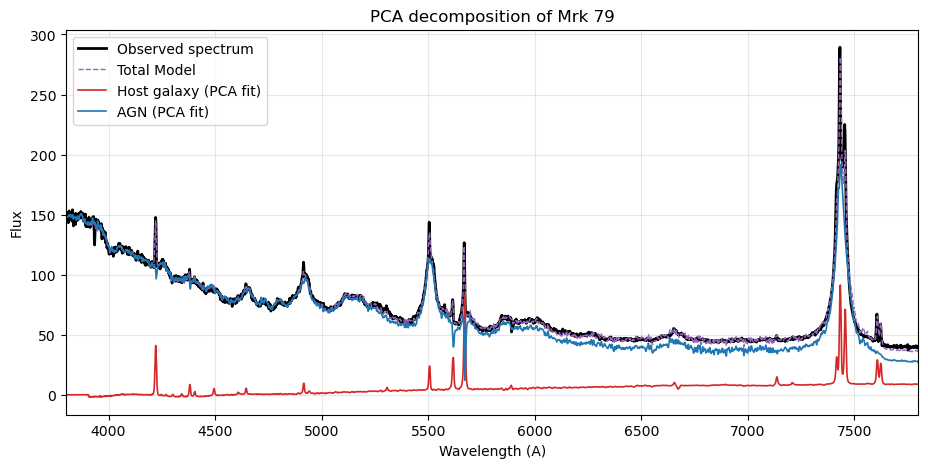

In [27]:
plt.figure(figsize=(11, 5))
plt.plot(wavelength, flux,         lw=2.0, color="black", ls='-', label="Observed spectrum")
plt.plot(wavelength, total_model,  lw=1.0, color="C4",  ls='--',  label="Total Model")
plt.plot(wavelength, galaxy_model, lw=1.2, color="C3",  ls='-',   label="Host galaxy (PCA fit)")
plt.plot(wavelength, agn_model,    lw=1.2, color="C0",  ls='-',   label="AGN (PCA fit)")
plt.xlim(3800, 7800)
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.title("PCA decomposition of Mrk 79")
plt.legend()
plt.show()

### Exercise 2 — Subtract the host galaxy

The pure AGN spectrum (what the black hole's gas alone is emitting) is
just the observed spectrum minus the galaxy model. Fill in the blank below.

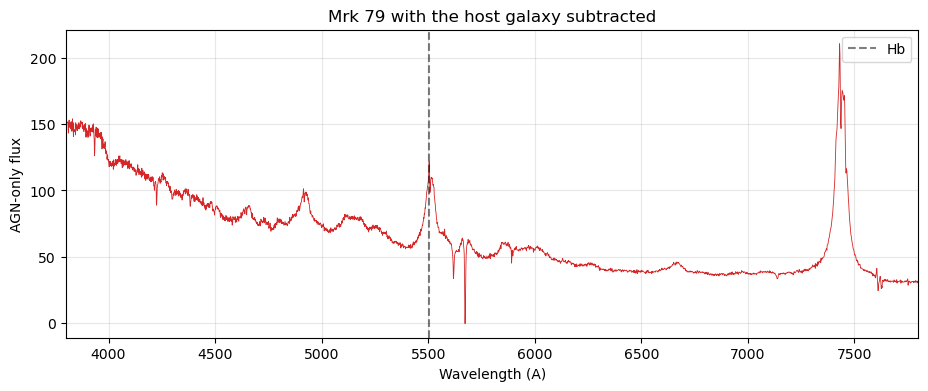

In [30]:
# === Exercise 2 ===
# Replace `None` below with the formula that gives the AGN-only spectrum.
# Hint: it's the observed flux minus the galaxy model from the previous cell.

agn_only = flux - galaxy_model #None       # <-- YOUR CODE HERE

if agn_only is None:
    print("TO DO: replace `None` above with your formula, then re-run this cell.")
else:
    plt.figure(figsize=(11, 4))
    plt.plot(wavelength, agn_only, lw=0.6, color="C3")
    plt.axvline(hbeta_obs, color="k", ls="--", alpha=0.5, label="Hb")
    plt.xlim(3800, 7800)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("AGN-only flux")
    plt.title("Mrk 79 with the host galaxy subtracted")
    plt.legend()
    plt.show()

## 3. Measure the AGN continuum at 5100 Å

To weigh the black hole we need two ingredients:

**(a)** The width of the broad Hβ line (next section).
**(b)** How bright the AGN's continuum is at 5100 Å (rest frame).

Why 5100 Å? It's a wavelength region with relatively few emission lines, so it
gives a clean snapshot of the AGN's continuum. Astronomers traditionally
measure the **monochromatic luminosity** $\lambda L_\lambda(5100\,\text{Å})$ and
report it as a brightness number for the AGN.

In [33]:
# Observed-frame wavelength of rest-frame 5100 A
lam_5100_obs = 5100.0 * (1 + z)

# Take a small window (+/-20 A) around it and use the median to be robust to noise
window = (wavelength > lam_5100_obs - 20) & (wavelength < lam_5100_obs + 20)
f_5100_obs_units = np.median(agn_only[window])

print(f"Rest-frame 5100 A lands at {lam_5100_obs:.1f} A in the observed frame.")
print(f"AGN flux density there (SDSS units of 10^-17 erg/s/cm^2/A): {f_5100_obs_units:.2f}")

# Convert SDSS units (10^-17 erg/s/cm^2/A) to physical erg/s/cm^2/A
f_lambda = f_5100_obs_units * 1e-17

# Luminosity distance from the redshift, using the Planck 2018 cosmology
d_L_cm = cosmo.luminosity_distance(z).to(u.cm).value
print(f"Luminosity distance to Mrk 79: {d_L_cm:.2e} cm")

# lamL_lam(5100, rest)  =  4pi d_L^2 * lam_obs * f_lam,obs
# (the units work out because the wavelength's A cancels f_lam's per-A)
lam_L_lam = 4 * np.pi * d_L_cm**2 * lam_5100_obs * f_lambda  # erg/s

print(f"\n--> lam L_lam(5100 A) = {lam_L_lam:.2e}  erg/s")
print(f"    log10(lam L_lam)   = {np.log10(lam_L_lam):.2f}")


Rest-frame 5100 A lands at 5774.7 A in the observed frame.
AGN flux density there (SDSS units of 10^-17 erg/s/cm^2/A): 49.65
Luminosity distance to Mrk 79: 1.98e+27 cm

--> lam L_lam(5100 A) = 1.42e+44  erg/s
    log10(lam L_lam)   = 44.15


For comparison, the Sun's bolometric luminosity is about 3.8 × 10³³ erg/s.
A typical Seyfert-1 AGN like Mrk 79 has λL_λ(5100) ≈ 10⁴³–10⁴⁴ erg/s — that's
*billions* of times the Sun's output, all from gas falling onto a single black
hole.

## 4. Fit the broad Hβ line

Now the fun part. The broad Hβ bump in the AGN-only spectrum is produced by gas
clouds whirling around the black hole at thousands of km/s. The faster they
move, the **wider** the bump (Doppler effect). So the bump's width tells us the
gas's speed.

We'll fit the Hβ region with a simple model:

$$f(\lambda) \;=\; a \lambda + b \;+\; \underbrace{N e^{-(\lambda-\lambda_0)^2 / (2 \sigma_n^2)}}_{\text{narrow Hβ}} \;+\; \underbrace{B e^{-(\lambda-\lambda_0)^2 / (2 \sigma_b^2)}}_{\text{broad Hβ}}$$

Read this as: **straight-line continuum + narrow Gaussian + broad Gaussian**.
The two Gaussians share their center at the redshifted Hβ wavelength but have
different widths and amplitudes. We use `scipy.optimize.curve_fit` to find the
six numbers $(a, b, N, \sigma_n, B, \sigma_b)$ that fit the data best.

In [37]:
def hbeta_model(lam, a, b, N, sigma_n, B, sigma_b):
    """Linear continuum + narrow Gaussian + broad Gaussian, all centered on Hb."""
    cont   = a * lam + b
    narrow = N * np.exp(-0.5 * ((lam - hbeta_obs) / sigma_n) ** 2)
    broad  = B * np.exp(-0.5 * ((lam - hbeta_obs) / sigma_b) ** 2)
    return cont + narrow + broad

In [39]:
def hbeta_model_offset(lam, a, b, N, sigma_n, B, sigma_b, xn, xb):
    """Linear continuum + narrow Gaussian + broad Gaussian, all centered on Hb."""
    cont   = a * lam + b
    narrow = N * np.exp(-0.5 * ((lam - hbeta_obs - xn) / sigma_n) ** 2)
    broad  = B * np.exp(-0.5 * ((lam - hbeta_obs - xb) / sigma_b) ** 2)
    return cont + narrow + broad

### Pick the fit window

We restrict the fit to a small region around Hβ. We also **mask out** the
nearby [O III] doublet (4959 + 5007 Å rest frame), because those narrow lines
would confuse the fit — we don't want the model trying to fit them with one of
our Gaussians.

Fitting 196 points in the Hb region (excluding [O III] doublet).


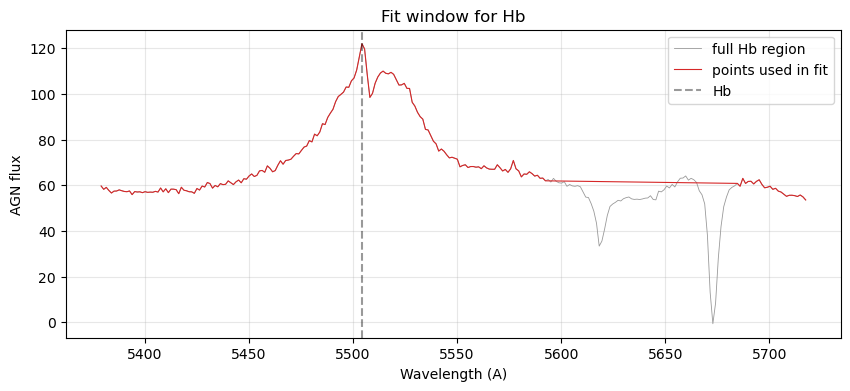

In [42]:
# Window: rest-frame 4750 to 5050 A, redshifted to observed frame
lo, hi = 4750 * (1+z), 5050 * (1+z)
in_window = (wavelength > lo) & (wavelength < hi)

# Mask: exclude rest-frame 4940-5020 A (the [O III] doublet)
oiii_lo, oiii_hi = 4940 * (1+z), 5020 * (1+z)
mask = in_window & ~((wavelength > oiii_lo) & (wavelength < oiii_hi))

x_fit = wavelength[mask]
y_fit = agn_only[mask]
print(f"Fitting {len(x_fit)} points in the Hb region (excluding [O III] doublet).")

plt.figure(figsize=(10, 4))
plt.plot(wavelength[in_window], agn_only[in_window], lw=0.6, color="0.6", label="full Hb region")
plt.plot(x_fit, y_fit, lw=0.8, color="C3", label="points used in fit")
plt.axvline(hbeta_obs, color="k", ls="--", alpha=0.4, label="Hb")
plt.xlabel("Wavelength (A)")
plt.ylabel("AGN flux")
plt.legend()
plt.title("Fit window for Hb")
plt.show()

### Run the fit

`curve_fit` needs an *initial guess* for each parameter so it knows where to
start searching. The guesses don't have to be perfect, just in the ballpark.

In [163]:
# Initial guesses
p0 = [
    0.0,                # a   slope of continuum
    np.median(y_fit),   # b   continuum level
    np.max(y_fit),      # N   narrow Gaussian amplitude
    3.0,                # sigma_n  narrow width in A
    np.max(y_fit) / 3,  # B   broad Gaussian amplitude
    50.0,               # sigma_b  broad width in A (~3000 km/s)
]

# Reasonable bounds keep the fit physical: amplitudes positive, widths positive
bounds = (
    [-np.inf, -np.inf, 0.0,  0.5, 0.0,  5.0],   # lower
    [ np.inf,  np.inf, 1e6, 10.0, 1e6, 200.0],  # upper
)

popt, pcov = curve_fit(hbeta_model, x_fit, y_fit, p0=p0, bounds=bounds, maxfev=10000)
a, b_fit, N, sigma_n, B, sigma_b = popt

print("Fitted parameters:")
print(f"  continuum:     a = {a:.4f},  b = {b_fit:.2f}")
print(f"  narrow Hb:     amplitude = {N:.2f},  sigma = {sigma_n:.2f} A")
print(f"  broad  Hb:     amplitude = {B:.2f},  sigma = {sigma_b:.2f} A")

Fitted parameters:
  continuum:     a = 0.0132,  b = -13.36
  narrow Hb:     amplitude = 16.58,  sigma = 1.47 A
  broad  Hb:     amplitude = 46.56,  sigma = 25.45 A


In [46]:
# Initial guesses
p0_offset = [
    0.0,                # a   slope of continuum
    np.median(y_fit),   # b   continuum level
    np.max(y_fit),      # N   narrow Gaussian amplitude
    3.0,                # sigma_n  narrow width in A
    np.max(y_fit) / 3,  # B   broad Gaussian amplitude
    50.0,               # sigma_b  broad width in A (~3000 km/s)
    0.0,                # offset of narrow Hb in A 
    0.0                # offset of broad Hb in A
]

# Reasonable bounds keep the fit physical: amplitudes positive, widths positive
bounds_offset = (
    [-np.inf, -np.inf, 0.0,  0.5, 0.0,  5.0, -10.0, -10.0],   # lower
    [ np.inf,  np.inf, 1e6, 10.0, 1e6, 200.0, 10.0, 10.0],  # upper
)

popt_offset, pcov_offset = curve_fit(hbeta_model_offset, x_fit, y_fit, p0=p0_offset, bounds=bounds_offset, maxfev=10000)
a, b_fit, N, sigma_n, B, sigma_b, xn, xb = popt_offset

print("Fitted parameters:")
print(f"  continuum:     a = {a:.4f},  b = {b_fit:.2f}")
print(f"  narrow Hb:     amplitude = {N:.2f},  sigma = {sigma_n:.2f} A")
print(f"  broad  Hb:     amplitude = {B:.2f},  sigma = {sigma_b:.2f} A")
print(f"  narrow  Hb:     offset = {xn:.2f} A")
print(f"  broad   Hb:     offset = {xb:.2f} A")

Fitted parameters:
  continuum:     a = 0.0048,  b = 32.96
  narrow Hb:     amplitude = 16.38,  sigma = 1.40 A
  broad  Hb:     amplitude = 48.11,  sigma = 24.20 A
  narrow  Hb:     offset = 0.08 A
  broad   Hb:     offset = 6.00 A


### Plot the fit

This is the single most satisfying plot in the workbook. The blue curve should
nicely follow the data, with the broad red dashed Gaussian capturing the wide
"foot" of Hβ.

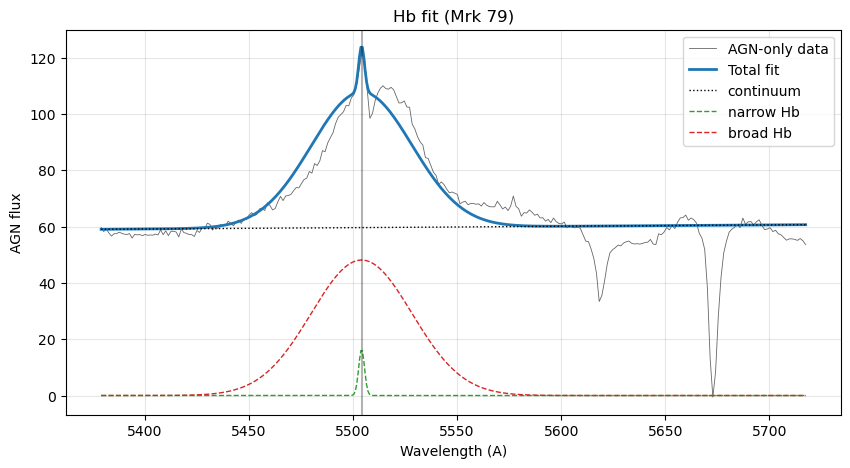

In [49]:
# Make a smooth grid for plotting the model
xx = np.linspace(x_fit.min(), x_fit.max(), 500)

cont_curve   = a * xx + b_fit
narrow_curve = N * np.exp(-0.5 * ((xx - hbeta_obs) / sigma_n) ** 2)
broad_curve  = B * np.exp(-0.5 * ((xx - hbeta_obs) / sigma_b) ** 2)
total_curve  = cont_curve + narrow_curve + broad_curve

plt.figure(figsize=(10, 5))
plt.plot(wavelength[in_window], agn_only[in_window], lw=0.6, color="0.4",
         label="AGN-only data")
plt.plot(xx, total_curve,  lw=2,   color="C0", label="Total fit")
plt.plot(xx, cont_curve,   lw=1, ls=":", color="k",  label="continuum")
plt.plot(xx, narrow_curve, lw=1, ls="--", color="C2", label="narrow Hb")
plt.plot(xx, broad_curve,  lw=1, ls="--", color="C3", label="broad Hb")
plt.axvline(hbeta_obs, color="k", alpha=0.3)
plt.xlabel("Wavelength (A)")
plt.ylabel("AGN flux")
plt.title("Hb fit (Mrk 79)")
plt.legend()
plt.show()

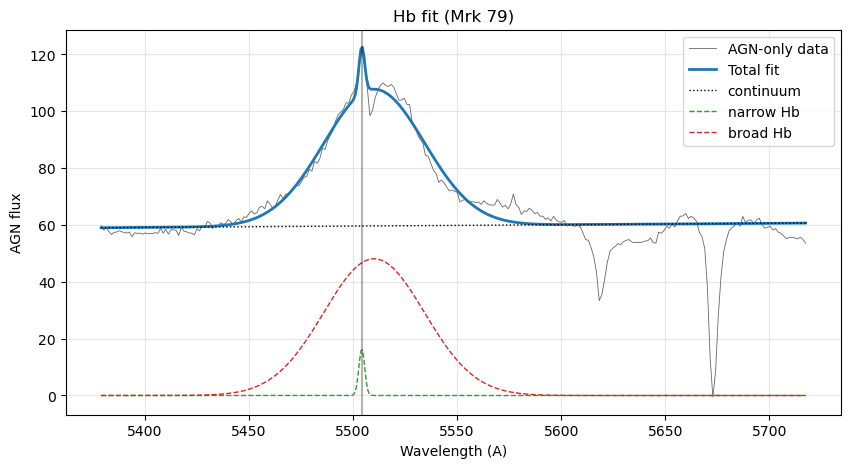

In [51]:
# Make a smooth grid for plotting the model
xx = np.linspace(x_fit.min(), x_fit.max(), 500)

cont_curve   = a * xx + b_fit
narrow_curve = N * np.exp(-0.5 * ((xx - hbeta_obs - xn) / sigma_n) ** 2)
broad_curve  = B * np.exp(-0.5 * ((xx - hbeta_obs - xb) / sigma_b) ** 2)
total_curve  = cont_curve + narrow_curve + broad_curve

plt.figure(figsize=(10, 5))
plt.plot(wavelength[in_window], agn_only[in_window], lw=0.6, color="0.4",
         label="AGN-only data")
plt.plot(xx, total_curve,  lw=2,   color="C0", label="Total fit")
plt.plot(xx, cont_curve,   lw=1, ls=":", color="k",  label="continuum")
plt.plot(xx, narrow_curve, lw=1, ls="--", color="C2", label="narrow Hb")
plt.plot(xx, broad_curve,  lw=1, ls="--", color="C3", label="broad Hb")
plt.axvline(hbeta_obs, color="k", alpha=0.3)
plt.xlabel("Wavelength (A)")
plt.ylabel("AGN flux")
plt.title("Hb fit (Mrk 79)")
plt.legend()
plt.show()

### Convert width into velocity

The broad Gaussian's **FWHM** (full width at half maximum) in wavelength units is

$$\text{FWHM}_\lambda = 2 \sqrt{2 \ln 2} \;\sigma_b \approx 2.355 \,\sigma_b$$

The Doppler formula turns wavelength width into velocity:

$$\text{FWHM}_v = \frac{\text{FWHM}_\lambda}{\lambda_0} \times c$$

where $c = 3 \times 10^5$ km/s is the speed of light and $\lambda_0$ is the
rest-frame wavelength of Hβ.

In [54]:
# === Exercise 3 ===
# Replace each `None` with your formula, then re-run.
# Hint 1: FWHM in A = 2.355 * sigma_b
# Hint 2: FWHM in km/s = (FWHM_A / hbeta_obs) * c

c_kms = 3.0e5            # speed of light in km/s

fwhm_angstroms =  2.355 * sigma_b #None    # <-- YOUR CODE HERE
fwhm_kms       =  (fwhm_angstroms / hbeta_obs) * c_kms #None    # <-- YOUR CODE HERE

if fwhm_angstroms is None or fwhm_kms is None:
    print("TO DO: replace the `None` values above with your formulas, then re-run.")
else:
    print(f"Broad Hb FWHM = {fwhm_angstroms:.1f} A (observed) ~ {fwhm_kms:.0f} km/s")
    # A typical Seyfert-1 has FWHM(Hb) ~ 2000-10000 km/s. Does our number look right?

Broad Hb FWHM = 57.0 A (observed) ~ 3107 km/s


## 5. Compute the black-hole mass

Combining the broad-line speed and the AGN's brightness gives us the mass! The
formula is from Vestergaard & Peterson (2006) — a standard "single-epoch"
black-hole mass estimator that astronomers actually use in research papers:

$$\log_{10}\left(\frac{M_\bullet}{M_\odot}\right) \;=\; 6.91 \;+\; 2 \log_{10}\!\left(\frac{\text{FWHM}_\text{Hβ}}{1000 \text{ km/s}}\right) \;+\; 0.5 \log_{10}\!\left(\frac{\lambda L_\lambda(5100)}{10^{44}\,\text{erg/s}}\right)$$

In words: the more massive the black hole, the deeper its gravitational pull,
and (a) the faster gas swirls around it (bigger FWHM) and (b) the more
luminous it is. Two simple measurements → one mass.

In [56]:
# === Exercise 4 ===
# Replace `None` below with the formula for term2, then re-run.
# Hint: term2 = 0.5 * log10( lam_L_lam / 1e44 )

term1 = 2 * np.log10(fwhm_kms / 1000.0)
term2 = 0.5*np.log10(lam_L_lam/1.0e44)  #None      # <-- YOUR CODE HERE

if term2 is None:
    print("TO DO: replace `None` above with your formula, then re-run this cell.")
else:
    log_M = 6.91 + term1 + term2
    M_bh  = 10 ** log_M       # in solar masses
    print(f"log10(M_BH / M_sun) = {log_M:.2f}")
    print(f"M_BH = {M_bh:.2e}  M_sun")
    print(f"     ~ {M_bh/1e6:.0f} million times the mass of the Sun")

log10(M_BH / M_sun) = 7.97
M_BH = 9.34e+07  M_sun
     ~ 93 million times the mass of the Sun


### How does our number compare?

Mrk 79's black-hole mass has been measured many times by professionals using
**reverberation mapping** — a much harder technique that watches how broad-line
brightness lags continuum brightness. Their answer is

$$\log_{10}(M_\bullet / M_\odot) \approx 7.7 \pm 0.1 \quad (\text{Peterson et al. 2004})$$

i.e., about **5 × 10⁷ M☉**. If your number is in the range 10⁷–10⁸ M☉,
**congratulations** — you just measured a real supermassive black hole's mass
with high-school-level math.

> Why isn't our answer perfect? Single-epoch estimators (which we used) have a
> ~0.4 dex (factor of ~2.5) scatter. They're great for surveys of millions of
> AGN, less precise for any single object. The professional value is more
> trustworthy because they monitored Mrk 79's variability for *years*.


## 6. Stretch goals (pick any)

If you finish early, try one or more of these.

### Stretch A — Try a different AGN

Pick another row from the catalog and re-run sections 1–5. The bundled FITS
file is only for Mrk 79, so to try a new target you'll need internet:

```python
from astroquery.sdss import SDSS
spec_list = SDSS.get_spectra(plate=2351, mjd=53772, fiberID=392)
spec = spec_list[0]
spec.writeto("content/spec_2351_53772_392.fits", overwrite=True)
# then change spec_path and z to match the new file
```

You can find good candidates by browsing `content/table_dr16_qso_krc213.csv` —
look for low-redshift, high-S/N entries (the column called `Column1` is the
redshift).

### Stretch B — Bolometric luminosity and Eddington ratio

The total luminosity (across all wavelengths) of an AGN is roughly **9× the
optical λL_λ(5100)** measurement. The "Eddington luminosity" is the maximum
brightness a black hole of mass $M$ can have:

$$L_\text{Edd} = 1.26 \times 10^{38} \, (M / M_\odot) \;\;\text{erg/s}$$

The Eddington ratio $L_\text{bol} / L_\text{Edd}$ tells us how *hard* the black
hole is feeding. Active Seyferts are usually 0.01–1.0.

```python
L_bol = 9 * lam_L_lam
L_edd = 1.26e38 * M_bh
print(f"Bolometric L = {L_bol:.2e} erg/s")
print(f"Eddington   = {L_edd:.2e} erg/s")
print(f"L/L_Edd     = {L_bol/L_edd:.3f}")
```

### Stretch C — Improve the PCA decomposition

Try restricting to only the first **3 galaxy** + **5 quasar** templates instead
of all 60. Does the fit get worse? By how much? (Hint: change the
`load_template` loops to use `galaxy_files[:3]` and `quasar_files[:5]`.)

### Stretch D — Where did the [O III] go?

Re-do the Hβ fit *without* masking [O III] (the `mask` step). What happens to
the broad Gaussian's width? Why?

### Stretch E — How to improve the broad and narrow Hβ fits?

Re-do the Hβ fit by introducing wavelength *offsets* to both broad and narrow components. What happens to the fits?
How would you translate these offsets in an astrophysical sense?

## Summary

You just:

1. Loaded a real SDSS spectrum from a FITS file.
2. Used **PCA** with 60 spectral templates to split it into a host galaxy
   component and an AGN component.
3. Measured the AGN's continuum brightness at 5100 Å and turned it into
   $\lambda L_\lambda$ via the luminosity distance.
4. Fit the broad Hβ line as a Gaussian and turned its width into a velocity
   in km/s.
5. Combined velocity + brightness in the **Vestergaard-Peterson formula** to
   weigh a supermassive black hole.

This is essentially the same pipeline professional astronomers use to weigh
*hundreds of thousands* of black holes from SDSS. Now you've done one too. 🌌
